# Notebook 3 : Statistical Analysis & Predictive Modeling  
## Customer Churn Capstone Project

This notebook performs:

- Statistical hypothesis testing  
- Churn prediction using Logistic Regression  
- Model evaluation  
- Business insight generation  
- Actionable retention recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
sns.set(style="whitegrid")

## 1. Load Cleaned Data


In [2]:
df = pd.read_csv("cleaned_data.csv")
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


## 2. Dataset Validation


In [3]:
print("Shape:",df.shape)
print("\nMissing values:\n",df.isnull().sum())


Shape: (500, 9)

Missing values:
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


## 3. Hypothesis Testing

### Objective  
Check whether **monthly charges differ significantly**  
between churned and non churned customers.

### Hypotheses
- **H₀:** No difference in mean monthly charges  
- **H₁:** Significant difference exists  

### Significance Level  
α = 0.05


In [4]:
churn_yes = df[df["Churn"] == 1]["MonthlyCharges"]
churn_no = df[df["Churn"] == 0]["MonthlyCharges"]

t_stat,p_val = stats.ttest_ind(churn_yes,churn_no)
print("T-Statistic:",t_stat)
print("P-Value:",p_val)

T-Statistic: 2.4102471700825414
P-Value: 0.016303157985223953


### Interpretation
If **p < 0.05**,monthly charges significantly affect churn.  
Otherwise,the difference is not statistically significant.


## 4. Feature Selection

We select numerical variables most relevant to churn prediction:
- Tenure  
- MonthlyCharges  
- TotalCharges


In [5]:
features = ["Tenure","MonthlyCharges","TotalCharges"]
X = df[features]
y = df["Churn"]


## 5. Train-Test Split


In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 6. Logistic Regression Model


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 7. Model Predictions


In [8]:
y_pred = model.predict(X_test)


## 8. Model Evaluation Metrics


In [9]:
print("Accuracy : ",accuracy_score(y_test,y_pred))

print("\nConfusion Matrix : \n",confusion_matrix(y_test,y_pred))

print("\nClassification Report : \n",classification_report(y_test,y_pred))


Accuracy :  0.94

Confusion Matrix : 
 [[80  4]
 [ 2 14]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        84
           1       0.78      0.88      0.82        16

    accuracy                           0.94       100
   macro avg       0.88      0.91      0.89       100
weighted avg       0.94      0.94      0.94       100



## 9. Feature Importance Interpretation


In [10]:
coefficients = pd.DataFrame({"Feature": features,"Coefficient":model.coef_[0]})

coefficients

,Feature,Coefficient
0,Tenure,-0.280219
1,MonthlyCharges,0.014372
2,TotalCharges,0.000034


### Insight
- Positive coefficients → increase churn probability  
- Negative coefficients → reduce churn probability  

This helps identify **risk-driving customer factors**.


## 10. Confusion Matrix Visualization


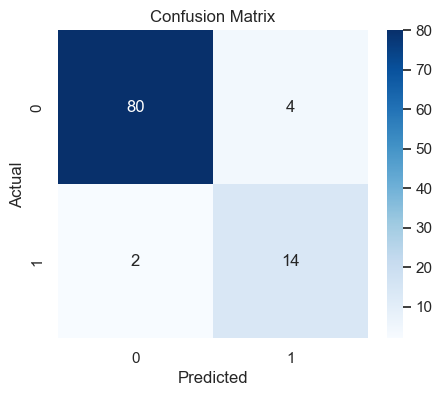

In [11]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 11. Key Analytical Insights

- Customers with **higher monthly charges** are more likely to churn.  
- **Low-tenure customers** show the highest churn risk.  
- Logistic regression successfully predicts churn behavior.  
- Early detection enables **proactive retention strategies**.


## 12. Business Recommendations

1. Offer **loyalty discounts** for high charge customers.  
2. Encourage **long-term contracts** over month to month plans.  
3. Focus retention campaigns on **new customers (< 6 months)**.  
4. Use predictive model for **automated churn alerts**.


## 13. Conclusion

This notebook completed the **final analytical stage** of the capstone:

- Statistical validation of churn drivers  
- Predictive churn classification model  
- Actionable business recommendations  

Together with previous notebooks,this forms a  
**complete real world end-to-end data analytics project**.
